## **Práctica 6 - Análisis y preprocesamiento de texto**
- Lectura y análisis preliminar del dataset.
- Distribuciones.
- Preprocesamiento de textos.
- Nubes de palabras.
- Relación entre longitud de textos y sentimiento.
- Palabras más frecuentes por sentimiento.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import nltk
from nltk.corpus import stopwords
from collections import Counter
import string

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\mpacc\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


#### **Lectura del Dataset**

In [ ]:
# Lectura del dataset

# Vista de los datos
df.head()

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


In [3]:
df.describe()

,tweet_id,airline_sentiment_confidence,negativereason_confidence,retweet_count
count,1.464000e+04,14640.000000,10522.000000,14640.000000
mean,5.692184e+17,0.900169,0.638298,0.082650
std,7.791112e+14,0.162830,0.330440,0.745778
min,5.675883e+17,0.335000,0.000000,0.000000
25%,5.685592e+17,0.692300,0.360600,0.000000
50%,5.694779e+17,1.000000,0.670600,0.000000
75%,5.698905e+17,1.000000,1.000000,0.000000
max,5.703106e+17,1.000000,1.000000,44.000000


In [4]:
df.describe(include='object')

,airline_sentiment,negativereason,airline,airline_sentiment_gold,name,negativereason_gold,text,tweet_coord,tweet_created,tweet_location,user_timezone
count,14640,9178,14640,40,14640,32,14640,1019,14640,9907,9820
unique,3,10,6,3,7701,13,14427,832,14247,3081,85
top,negative,Customer Service Issue,United,negative,JetBlueNews,Customer Service Issue,@united thanks,"[0.0, 0.0]",2015-02-24 09:54:34 -0800,"Boston, MA",Eastern Time (US & Canada)
freq,9178,2910,3822,32,63,12,6,164,5,157,3744


#### **Distribuciones**

#### Distribución por Sentimiento

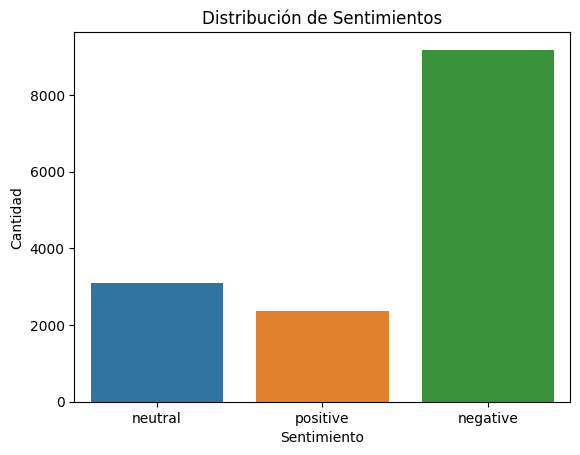

In [5]:
# Distribución por sentimiento
sns.countplot(data=df, x='airline_sentiment',
              hue='airline_sentiment', legend=False)
plt.title("Distribución de Sentimientos")
plt.xlabel("Sentimiento")
plt.ylabel("Cantidad")
plt.show()

#### Distribución por Zona horaria

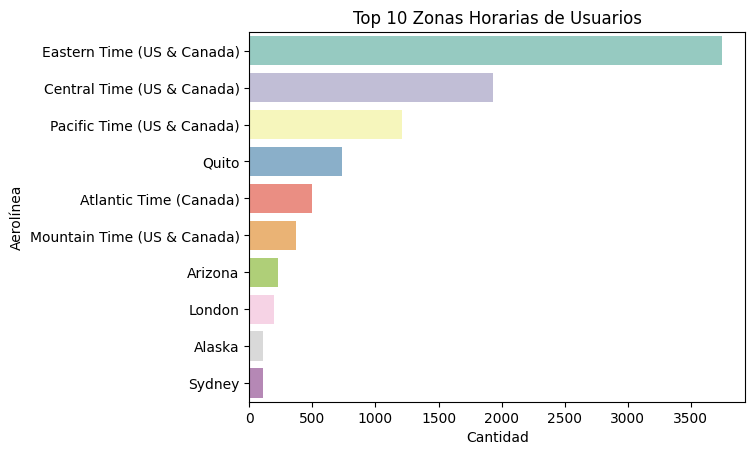

In [6]:
top_10_timezones = df['user_timezone'].value_counts().nlargest(10).index

# Filtrar el DataFrame para solo esas aerolíneas
df_top_timezones = df[df['user_timezone'].isin(top_10_timezones)]

# Gráfico de barras para las 10 aerolíneas más frecuentes
sns.countplot(data=df_top_timezones, y='user_timezone',
              hue='user_timezone', order=top_10_timezones,
              palette='Set3', legend=False)
plt.title("Top 10 Zonas Horarias de Usuarios")
plt.xlabel("Cantidad")
plt.ylabel("Aerolínea")
plt.show()

#### **Preprocesamiento de Textos**

In [7]:
def clean_text(text):
    text = text.lower()
    text = ''.join([char for char in text if char not in string.punctuation])
    tokens = text.split()
    tokens = [word for word in tokens if word not in stop_words and len(word) > 3]
    return " ".join(tokens)

df['clean_text'] = df['text'].apply(clean_text)

#### **Nubes de Palabras**

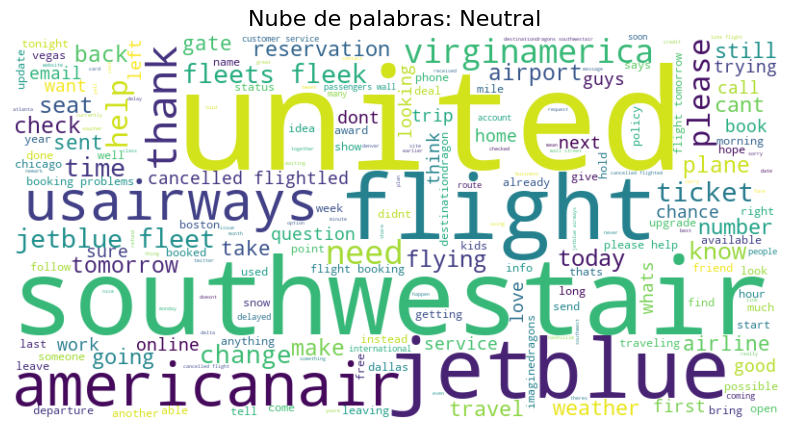

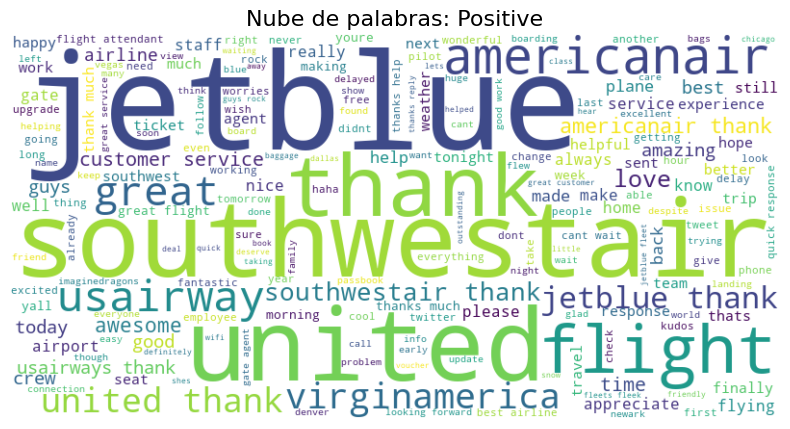

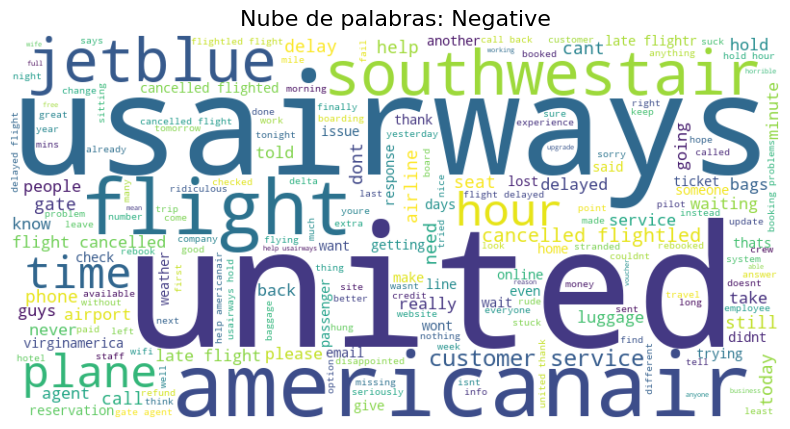

In [8]:
def plot_wordcloud(text, title):
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(" ".join(text))
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.title(title, fontsize=16)
    plt.show()

# Nube para cada sentimiento
for sentiment in df['airline_sentiment'].unique():
    subset = df[df['airline_sentiment'] == sentiment]
    plot_wordcloud(subset['clean_text'], f"Nube de palabras: {sentiment.capitalize()}")

#### **Relación entre longitud de textos y sentimiento**

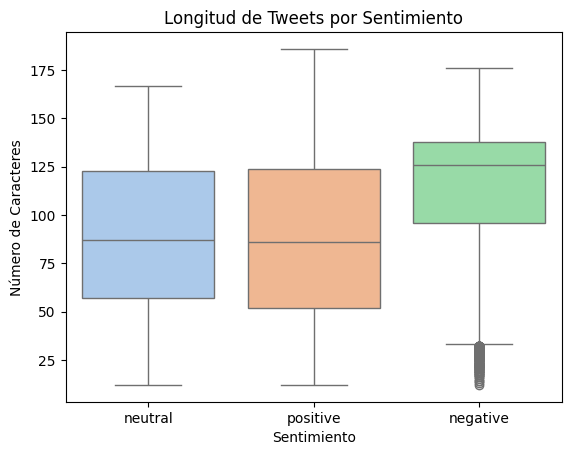

In [9]:
df['text_length'] = df['text'].apply(len)

# Boxplot por sentimiento
sns.boxplot(data=df, x='airline_sentiment', y='text_length',
            palette='pastel', hue='airline_sentiment')
plt.title("Longitud de Tweets por Sentimiento")
plt.xlabel("Sentimiento")
plt.ylabel("Número de Caracteres")
plt.show()

#### **Palabras frecuentes por sentimiento**

In [10]:
def most_common_words(texts, n=10):
    all_words = " ".join(texts).split()
    common_words = Counter(all_words).most_common(n)
    return pd.DataFrame(common_words, columns=['Palabra', 'Frecuencia'])

# Top palabras por sentimiento
for sentiment in df['airline_sentiment'].unique():
    print(f"\nPalabras más comunes en tweets {sentiment.upper()}:")
    common_df = most_common_words(df[df['airline_sentiment'] == sentiment]['clean_text'])
    print(common_df)


Palabras más comunes en tweets NEUTRAL:
         Palabra  Frecuencia
0         united         727
1   southwestair         663
2        jetblue         646
3         flight         599
4    americanair         495
5      usairways         398
6         please         179
7  virginamerica         174
8        flights         167
9           need         163

Palabras más comunes en tweets POSITIVE:
        Palabra  Frecuencia
0        thanks         608
1       jetblue         573
2  southwestair         569
3        united         517
4         thank         453
5        flight         371
6   americanair         348
7     usairways         273
8         great         233
9       service         159

Palabras más comunes en tweets NEGATIVE:
        Palabra  Frecuencia
0        flight        2900
1        united        2873
2     usairways        2368
3   americanair        2095
4  southwestair        1209
5       jetblue        1037
6     cancelled         920
7       service         